# Customer Segmentation using K-Means Clustering  
### Determining Optimal Clusters with the Elbow Method  

**Student ID:** 24155168

---

## Objective
This tutorial explores how K-Means clustering can segment customers based on purchasing behaviour.  
The Elbow Method and Silhouette Score are used to determine the optimal number of clusters.

### import libraries

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

### Load data

In [4]:
df = pd.read_csv("Mall_Customers.csv")

# Fix column name if needed
df.rename(columns={"Genre": "Gender"}, inplace=True)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Data Overview

We focus on:
- Annual Income (k$)
- Spending Score (1–100)

These features help capture customer purchasing behaviour.

### Raw Scatter Data

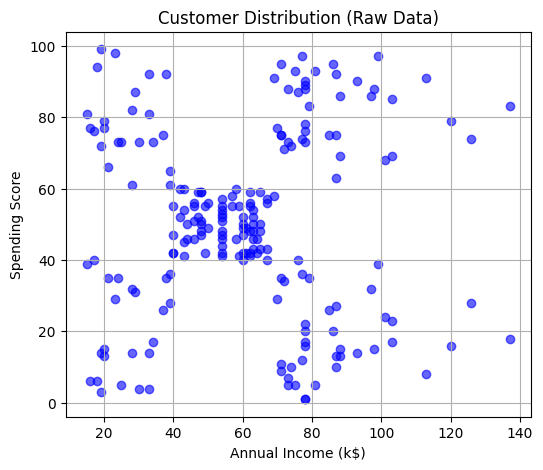

In [27]:
plt.figure(figsize=(6,5))

plt.scatter(df['Annual Income (k$)'],
            df['Spending Score (1-100)'],
            color='blue', alpha=0.6)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.title("Customer Distribution (Raw Data)")
plt.savefig("raw_data.png")
plt.grid(True)
plt.show()

### Prepare Data

In [18]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Elbow Plot

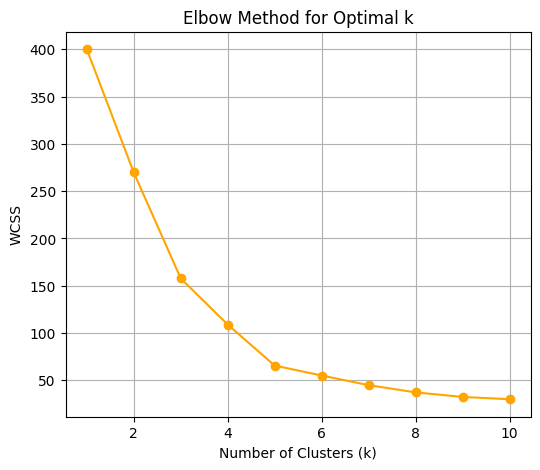

In [28]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,5))

plt.plot(range(1,11), wcss, marker='o', color='orange')

plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal k")
plt.savefig("elbow_method.png")
plt.grid(True)
plt.show()

### Silhouette Scores

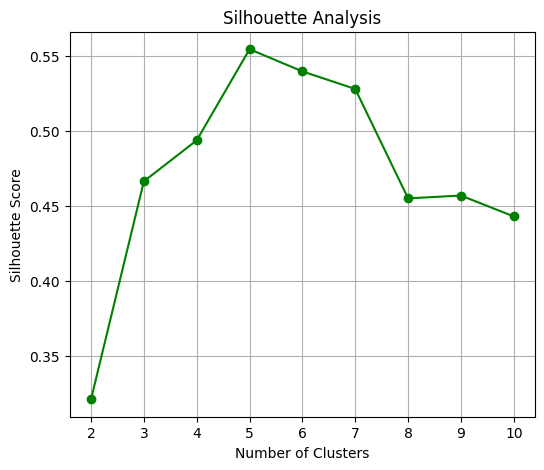

In [29]:
sil_scores = []

for i in range(2,11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

plt.figure(figsize=(6,5))

plt.plot(range(2,11), sil_scores, marker='o', color='green')

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.savefig("silhouette.png")
plt.grid(True)
plt.show()

### Train KMeans

In [9]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

### 2D Cluster Plot

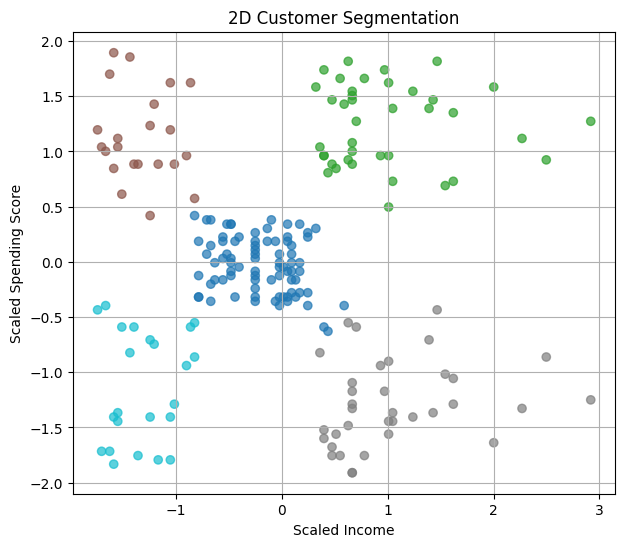

In [30]:
plt.figure(figsize=(7,6))

plt.scatter(X_scaled[:,0], X_scaled[:,1],
            c=clusters, cmap='tab10', alpha=0.7)

plt.xlabel("Scaled Income")
plt.ylabel("Scaled Spending Score")
plt.title("2D Customer Segmentation")
plt.savefig("2d_cluster.png")
plt.grid(True)
plt.show()

### Cluster Centers

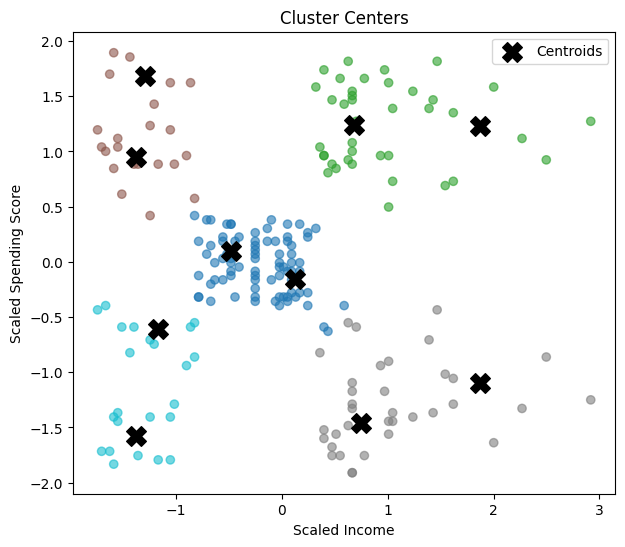

In [31]:
centers = kmeans.cluster_centers_

plt.figure(figsize=(7,6))

plt.scatter(X_scaled[:,0], X_scaled[:,1],
            c=clusters, cmap='tab10', alpha=0.6)

plt.scatter(centers[:,0], centers[:,1],
            s=200, c='black', marker='X', label='Centroids')

plt.xlabel("Scaled Income")
plt.ylabel("Scaled Spending Score")
plt.title("Cluster Centers")
plt.savefig("cluster_centers.png")
plt.legend()
plt.show()

### Original Scale Plot

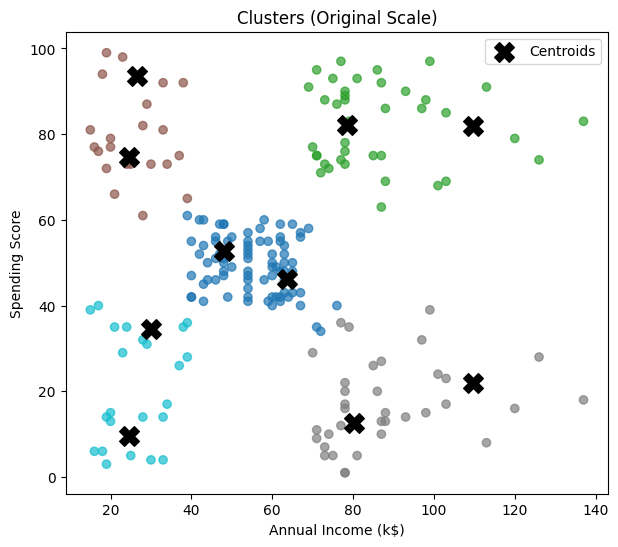

In [32]:
centers_original = scaler.inverse_transform(centers)

plt.figure(figsize=(7,6))

plt.scatter(df['Annual Income (k$)'],
            df['Spending Score (1-100)'],
            c=clusters, cmap='tab10', alpha=0.7)

plt.scatter(centers_original[:,0],
            centers_original[:,1],
            s=200, c='black', marker='X', label='Centroids')

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.title("Clusters (Original Scale)")
plt.savefig("original_scale.png")
plt.legend()
plt.show()

### Cluster Profiling

In [13]:
cluster_summary = df.groupby('Cluster')[[
    'Annual Income (k$)',
    'Spending Score (1-100)'
]].mean()

print(cluster_summary)

         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043


### Cluster Profiles Plot

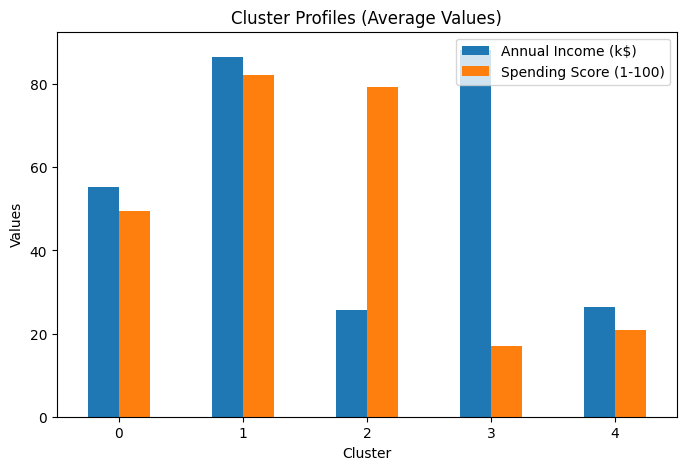

In [33]:
cluster_summary.plot(kind='bar', figsize=(8,5))

plt.title("Cluster Profiles (Average Values)")
plt.ylabel("Values")
plt.xticks(rotation=0)
plt.savefig("cluster_profiles.png")
plt.show()

### Cluster Sizes

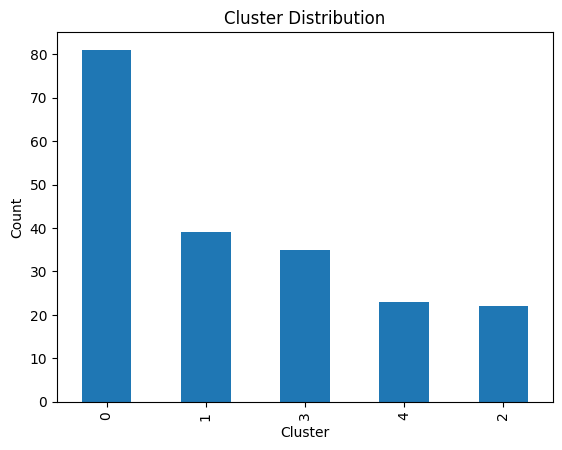

In [34]:
df['Cluster'].value_counts().plot(kind='bar')

plt.title("Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.savefig("cluster_distribution.png")
plt.show()

### 3D data preparation

In [23]:
X_3d = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

scaler_3d = StandardScaler()
X_3d_scaled = scaler_3d.fit_transform(X_3d)

### Train 3D KMeans

In [24]:
kmeans_3d = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters_3d = kmeans_3d.fit_predict(X_3d_scaled)

### 3D Cluster Plot

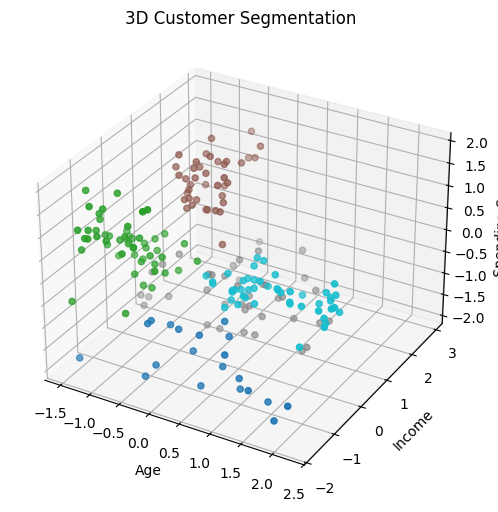

In [35]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_3d_scaled[:,0],
    X_3d_scaled[:,1],
    X_3d_scaled[:,2],
    c=clusters_3d,
    cmap='tab10'
)

ax.set_xlabel("Age")
ax.set_ylabel("Income")
ax.set_zlabel("Spending Score")
plt.savefig("3d_cluster.png")
plt.title("3D Customer Segmentation")
plt.show()

### 3D Centroids

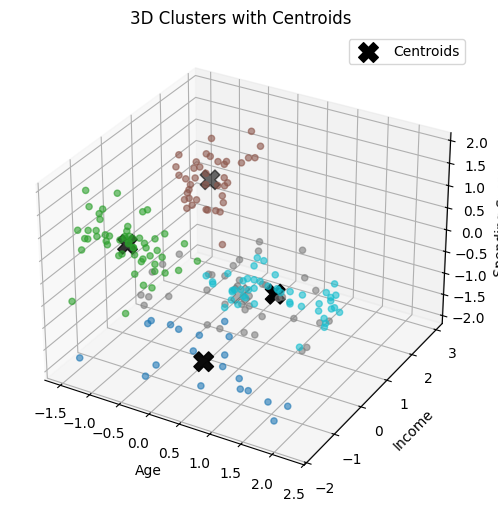

In [36]:
centers_3d = kmeans_3d.cluster_centers_

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_3d_scaled[:,0],
    X_3d_scaled[:,1],
    X_3d_scaled[:,2],
    c=clusters_3d,
    cmap='tab10',
    alpha=0.6
)

ax.scatter(
    centers_3d[:,0],
    centers_3d[:,1],
    centers_3d[:,2],
    s=200,
    c='black',
    marker='X',
    label='Centroids'
)

ax.set_xlabel("Age")
ax.set_ylabel("Income")
ax.set_zlabel("Spending Score")

plt.title("3D Clusters with Centroids")
plt.legend()
plt.savefig("3d_centroids.png")
plt.show()

## Conclusion
- Customers form distinct behavioural groups
- High-income high-spending group represents premium customers
- Low-spending groups require targeted strategies
- 3D clustering reveals deeper segmentation patterns
- Combining multiple validation techniques improves clustering reliability